Title: PSL_cluster_bc.ipynb

Purpose: Make a clustering of large scale weather patterns

Author: Onno Nennecke on 03.06.2025 Modified: 10.06.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import cftime
# import datetime
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Importing functions
import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

# Find first ESM_run per unique ESM
unique_esms, first_indices = np.unique(ts_datasets['ESM'].values, return_index=True)

# Subset the dataset
subset_ds = ts_datasets.isel(ESM_run=first_indices)

# ts_datasets = subset_ds.copy()
ts_datasets

<xarray.Dataset> Size: 1GB
Dimensions:   (ESM_run: 100, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
Data variables:
    psl       (ESM_run, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

/tmp/ipykernel_1151169/4227401055.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


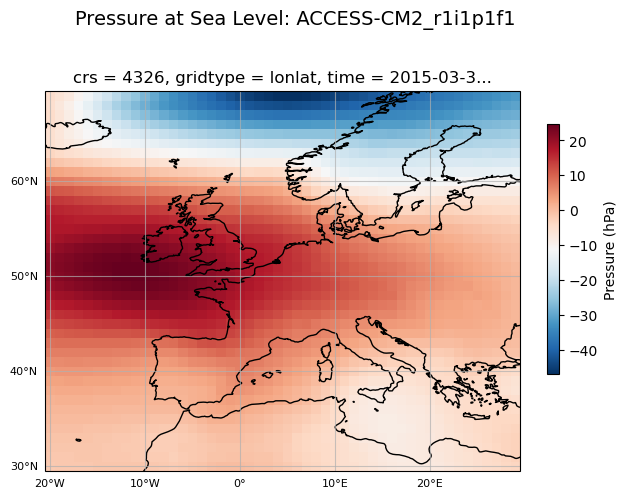

In [4]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run='ACCESS-CM2_r1i1p1f1').isel(time=89)

# Compute vmin/vmax as Python floats
vmin_da = tst['psl'].min() / 100
vmax_da = tst['psl'].max() / 100

# Force evaluation and extract a scalar
vmin = float(vmin_da.compute())
vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level: ACCESS-CM2_r1i1p1f1', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


# Clustering

In [5]:
# Determine the number of clusters
k = 5

In [6]:
# 1. Load PSL data
ts_datasets
psl = ts_datasets['psl']
# psl

In [7]:
# 2. Flatten each time‐slice
n_times = psl.sizes['time']
n_lat = psl.sizes['lat']
n_lon = psl.sizes['lon']
n_ESM = psl.sizes['ESM_run']
print(n_times)
print(n_lat)
print(n_lon)
print(n_ESM)
arr_flat = psl.values.reshape(n_times * n_ESM, n_lat * n_lon)

1820
40
50
100


In [8]:
'''
arr = psl.values # Extract the raw NumPy array: psl.values has shape (11, 1820, 40, 50)
arr.shape
# arr = np.transpose(arr, (1, 0, 2, 3)) # Reorder axes so that the run‐index is next to time
# arr.shape
# n_times, n_ESM, n_lat, n_lon = arr.shape # Flatten the first two dimensions into a single “sample” dimension, and flatten the last two dims into a single “feature” dimension:

n_ESM, n_times, n_lat, n_lon = arr.shape # Flatten the first two dimensions into a single “sample” dimension, and flatten the last two dims into a single “feature” dimension:
arr_flat = arr.reshape(n_times * n_ESM, n_lat * n_lon)

arr_flat.shape
'''

'\narr = psl.values # Extract the raw NumPy array: psl.values has shape (11, 1820, 40, 50)\narr.shape\n# arr = np.transpose(arr, (1, 0, 2, 3)) # Reorder axes so that the run‐index is next to time\n# arr.shape\n# n_times, n_ESM, n_lat, n_lon = arr.shape # Flatten the first two dimensions into a single “sample” dimension, and flatten the last two dims into a single “feature” dimension:\n\nn_ESM, n_times, n_lat, n_lon = arr.shape # Flatten the first two dimensions into a single “sample” dimension, and flatten the last two dims into a single “feature” dimension:\narr_flat = arr.reshape(n_times * n_ESM, n_lat * n_lon)\n\narr_flat.shape\n'

#### mit PCA

In [9]:
# !!! Takes ~1:30h if you run it on the full dataset !!!


# 2.1 Without standardization
X = arr_flat
# 2.2 PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X)  # shape: (n_times, n_eofs)
# X_pca

In [10]:
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (k, n_eofs)
# 4.1 Convert centroids back to original space
centroids = pca.inverse_transform(centroids_pca)  # shape (k, n_lat * n_lon)

In [11]:
# 5. Reshape centroids to lat/lon grid
centroids_reshaped = centroids.reshape(k, n_lat, n_lon)  # shape (k, n_lat, n_lon)

score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.18383864


In [ ]:
# !!! Takes ~6:40h if you run it on the full dataset !!!

# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=20, random_state=1)
    labels_k = km.fit_predict(X_pca)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X_pca, labels_k)
    silhouettes.append(silh)


In [ ]:
# Save k_range, inertias and silhouettes in a dataframe
df_results = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette': silhouettes
})
# Save the results to a CSV file
df_results.to_csv('/home/onennecke/psl_clustering/psl_kmeans_results_bc.csv', index=False)

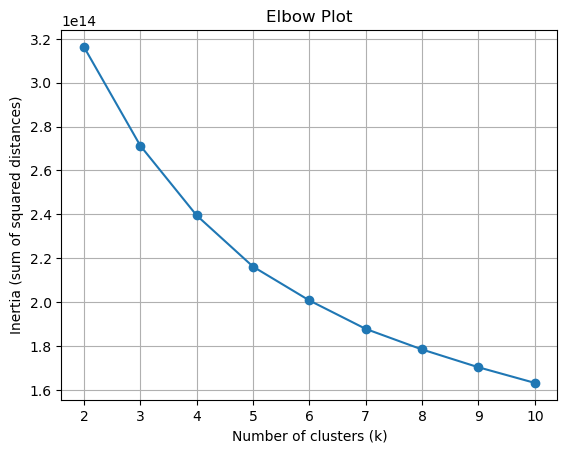

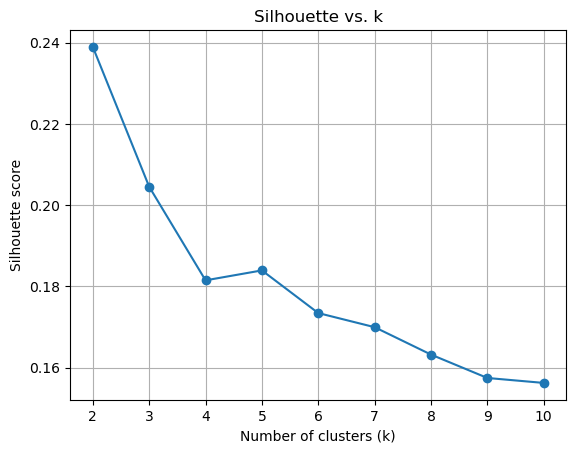

In [3]:
# Read the results from the CSV file
df_results = pd.read_csv('/home/onennecke/psl_clustering/psl_kmeans_results_bc.csv')


# Plot inertia (elbow)
plt.figure()
plt.plot(df_results['k'], df_results['inertia'], marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(df_results['k'], df_results['silhouette'], marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()

In [10]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X_pca)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_359868/191963972.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


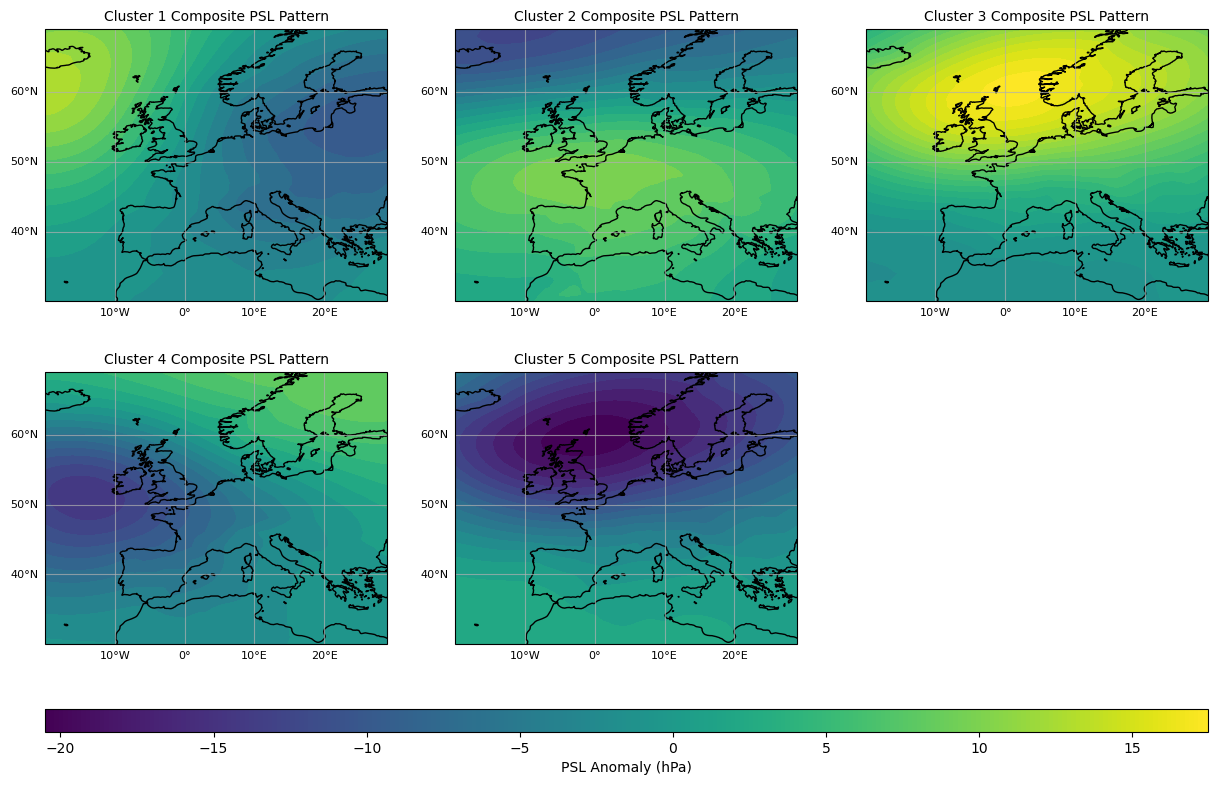

In [11]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


##### Look how the clusters are seasonaly distributed

In [12]:
ts_datasets['time'].values

array(['2015-01-01T00:00:00.000000000', '2015-01-02T00:00:00.000000000',
       '2015-01-03T00:00:00.000000000', ...,
       '2024-12-29T00:00:00.000000000', '2024-12-30T00:00:00.000000000',
       '2024-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

In [13]:
# ────────────── 1) Recover time‐coordinates for each “flattened” sample ──────────────

time_coords = ts_datasets['time'].values      # shape = (n_times,), dtype=datetime64

times_repeated = np.repeat(time_coords, n_ESM)  


In [14]:
# ────────────── 2) Build a small DataFrame with (time, cluster) ──────────────

df = pd.DataFrame({
    "time":    times_repeated,
    "cluster": labels
})
# df

In [15]:
# ────────────── 3) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"]  = pd.DatetimeIndex(df["time"]).month
df["season"] = df["month"].map(month_to_season)
# df


In [16]:
# ────────────── 4) Count how many samples of each cluster fall in each season ──────────────

# This gives you a table with index = cluster ID, columns = season, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)  
# e.g. monthly_counts.loc[2, "JJA"] is “how many cluster–2 days fall in summer (JJA).”

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
# Now each row sums to 1, so monthly_frac.loc[i, s] is the fraction of cluster i’s samples in season s.


In [17]:
monthly_frac
# Calculate the sum per month
monthly_sum = monthly_counts.sum(axis=0)
monthly_sum
# Oktober passt
# November passt
# Dezember passt
# Januar passt
# Februar passt
# März sind manchmal weniger wenn es ein Schaltjahr gab

month
1     31000
2     28000
3     31000
10    31000
11    30000
12    31000
dtype: int64

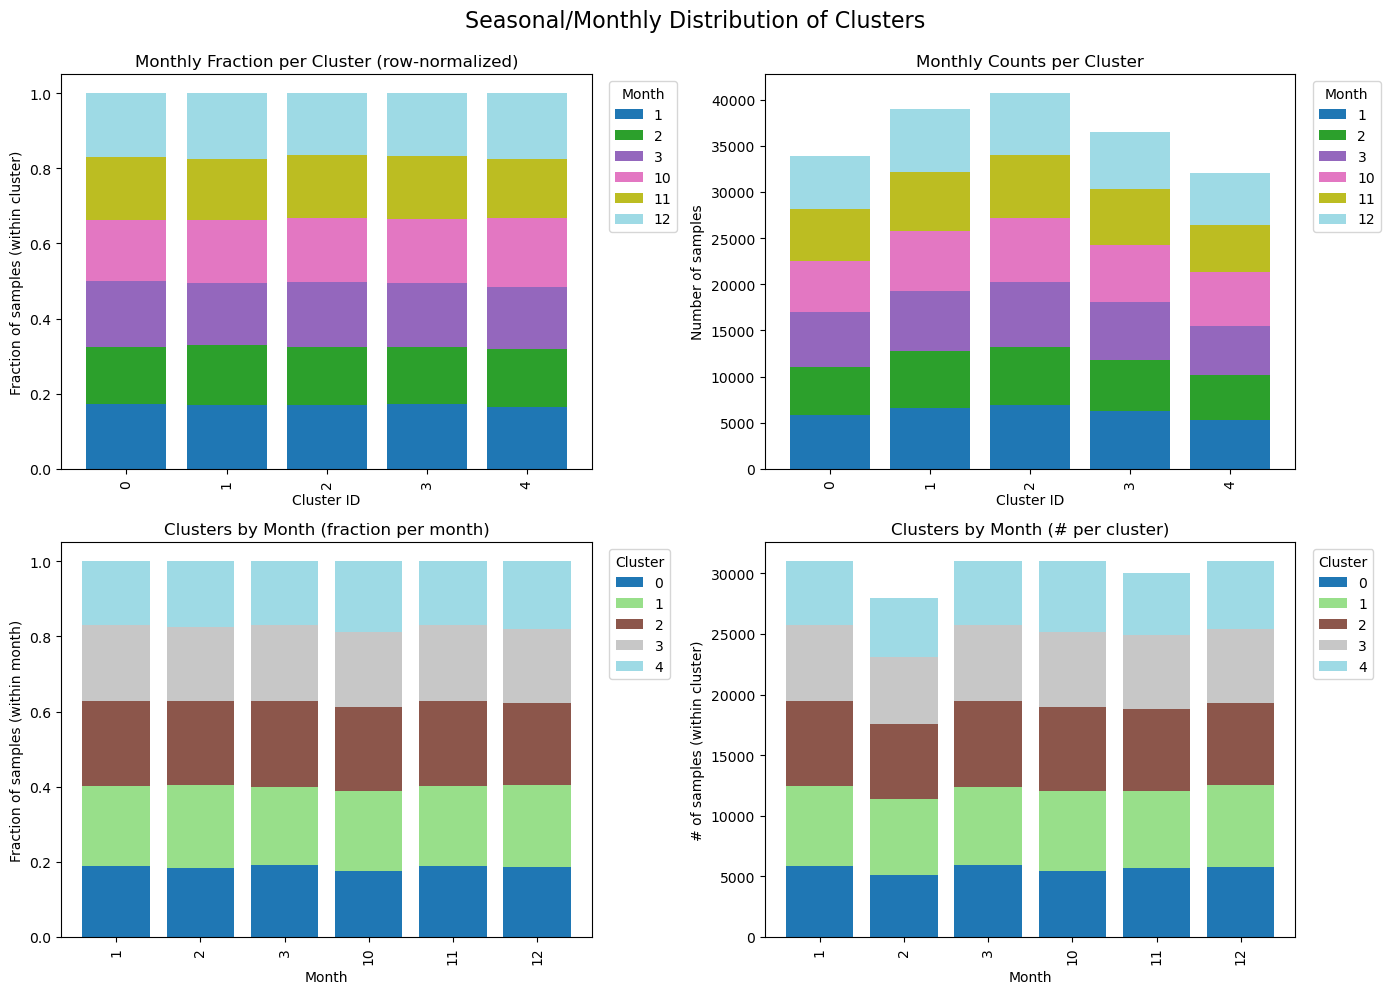

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 1) Top‐Left: monthly_frac (clusters on x‐axis, months stacked)
monthly_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
    width=0.8
)
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Fraction of samples (within cluster)")
axes[0].set_title("Monthly Fraction per Cluster (row‐normalized)")
axes[0].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Top‐Right: monthly_counts (clusters on x‐axis, months stacked)
monthly_counts.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab20",
    width=0.8
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Monthly Counts per Cluster")
axes[1].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Right: monthly_frac_within_month.T (months on x‐axis, clusters stacked; fraction within month)
monthly_frac_within_month = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

monthly_frac_within_month.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab20",
    width=0.8
)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraction of samples (within month)")
axes[2].set_title("Clusters by Month (fraction per month)")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Left: monthly_counts.T (months on x‐axis, clusters stacked; fraction within cluster)
monthly_counts.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    colormap="tab20",
    width=0.8
)
axes[3].set_xlabel("Month")
axes[3].set_ylabel("# of samples (within cluster)")
axes[3].set_title("Clusters by Month (# per cluster)")
axes[3].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")



# ────────────── D) Adjust layout ──────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Seasonal/Monthly Distribution of Clusters", fontsize=16, y=0.99)
plt.show()

----

In [19]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times},
    name    = "cluster_id",
)
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 100, time: 1820)> Size: 728kB
array([[3, 2, 2, ..., 3, 3, 3],
       [1, 1, 1, ..., 4, 4, 4],
       [4, 0, 3, ..., 0, 3, 3],
       ...,
       [2, 2, 2, ..., 0, 0, 0],
       [1, 1, 0, ..., 2, 2, 2],
       [4, 4, 4, ..., 4, 4, 4]], dtype=int32)
Coordinates:
  * ESM_run  (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p1f2'
  * time     (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31

In [22]:
labels_da.isel(ESM_run=0, time=0).values

array(3, dtype=int32)

/tmp/ipykernel_359868/1733983874.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


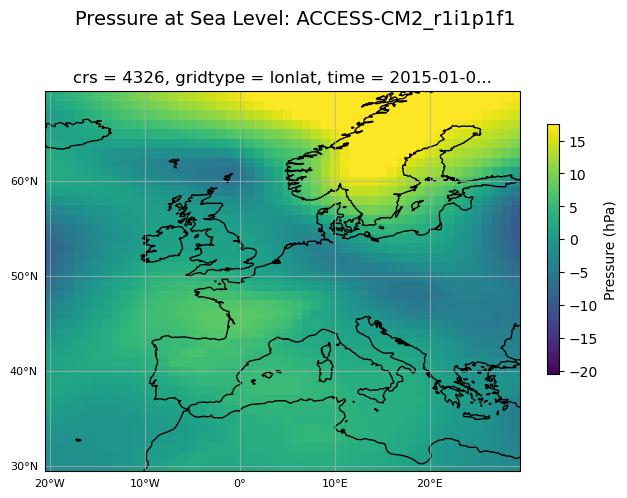

In [23]:
# Select a specific ESM run and one time step
tst = ts_datasets.isel(ESM_run=0, time=0)

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level: ACCESS-CM2_r1i1p1f1', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### Select relevant timesteps

In [24]:
# read csv file
LEE_1 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_1.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_7.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_14.csv')


In [30]:
esm_entries = LEE_1[LEE_1['ESM'] == unique_esms[2]]
esm_entries
count = 0
for esm in LEE_1['ESM'].unique():
    esm_entries = LEE_1[LEE_1['ESM'] == esm]
    count += len(esm_entries)
    print(esm, len(esm_entries))
    # if len(esm_entries) > 0:
    #     print(esm_entries['time'].values)
    #     print(esm_entries['cluster'].values)
    #     print('-------------------')
print('Total number of entries:', count)

ACCESS-CM2 90
BCC-CSM2-MR 50
CESM2 174
EC-Earth3 2985
ERA5_week 87
ERA5_wwd 132
GFDL-ESM4 59
KACE-1-0-G 106
MPI-ESM1-2-HR 581
MRI-ESM2-0 176
TaiESM1 25
UKESM1-0-LL 861
Total number of entries: 5326


In [31]:
esm_entries = LEE_1[LEE_1['ESM_run'] == LEE_1['ESM_run'].unique()[0]]
esm_entries
# Create an empty DataFrame with the same columns as LEE_1
exemplary_entries = LEE_1.iloc[0:0].copy()
exemplary_entries = pd.concat([exemplary_entries, esm_entries], ignore_index=True)
exemplary_entries

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00.000000000,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00.000000000,1446638400000000000,1446724800000000000,1446638400000000000,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00.000000000,1450267200000000000,1450353600000000000,1450267200000000000,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00.000000000,1481544000000000000,1481544000000000000,1481544000000000000,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73
5,2016-12-22 12:00:00,2016-12-22 12:00:00,2016-12-22 12:00:00.000000000,1482408000000000000,1482408000000000000,1482408000000000000,354,354,354,1,1378.789514,1378.789514,0.000000,1378.789514,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,83
6,2017-01-10 12:00:00,2017-01-10 12:00:00,2017-01-10 12:00:00.000000000,1484049600000000000,1484049600000000000,1484049600000000000,373,373,373,1,1430.609517,1430.609517,0.000000,1430.609517,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,102
7,2017-02-15 12:00:00,2017-02-15 12:00:00,2017-02-15 12:00:00.000000000,1487160000000000000,1487160000000000000,1487160000000000000,409,409,409,1,1398.413557,1398.413557,0.000000,1398.413557,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,138
8,2017-11-27 12:00:00,2017-11-28 12:00:00,2017-11-27 12:00:00.000000001,1511784000000000000,1511870400000000000,1511870400000000000,511,512,512,2,1392.493927,1382.761086,9.732841,2765.522172,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,58
9,2017-12-06 12:00:00,2017-12-06 12:00:00,2017-12-06 12:00:00.000000000,1512561600000000000,1512561600000000000,1512561600000000000,520,520,520,1,1385.857342,1385.857342,0.000000,1385.857342,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,67


In [ ]:
LEE_df['ESM_run'].unique()
LEE_1.sel(ESM )

In [26]:
# Select one exemplary entry from LEE_1 for each ESM values
def select_exemplary_entries(LEE_df, ESMs):
    exemplary_entries = []
    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            exemplary_entry = esm_entries.iloc[0]  # Select the first entry for each ESM
            exemplary_entries.append(exemplary_entry)
    return pd.DataFrame(exemplary_entries)
# LEE_1_subset = select_exemplary_entries(LEE_1, unique_esms)
# Select one the first run of each ESM from LEE_1
def select_first_run_entries(LEE_df, ESMs):
    first_run_entries = LEE_df.iloc[0:0].copy()

    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            first_run = esm_entries['ESM_run'].unique()[0]
            first_run_entry = esm_entries[esm_entries['ESM_run'] == first_run]
            first_run_entries = pd.concat([first_run_entries, first_run_entry], ignore_index=True)
    return first_run_entries

# LEE_1_subset = select_first_run_entries(LEE_1, unique_esms)
LEE_1_subset = LEE_1.copy()
# LEE_1_subset = LEE_1[0:10]
# LEE_1_subset

In [27]:
LEE_1_subset = LEE_1_subset[~LEE_1_subset['ESM'].isin(['ERA5_wwd', 'ERA5_week'])]
LEE_1_subset['ESM'].unique()

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1',
       'UKESM1-0-LL'], dtype=object)

In [32]:
LEE_1_subset

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00.000000000,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00.000000000,1446638400000000000,1446724800000000000,1446638400000000000,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00.000000000,1450267200000000000,1450353600000000000,1450267200000000000,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00.000000000,1481544000000000000,1481544000000000000,1481544000000000000,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5321,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00.000000000,2023-12-22 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.000000,1378.105975,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,82
5322,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00.000000000,2023-12-24 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.000000,1409.127953,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,84
5323,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00.000000000,2024-01-27 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.000000,1390.731921,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,117
5324,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00.000000000,2024-11-15 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.000000,1399.713515,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,45


In [28]:
# 3) Lookup per‐event cluster
#    assumes `LEE_1_subset` has cols ["date_start","ESM_run"]
LEE_1_subset["cluster_at_start"] = [
    labels_da.sel(time=dt, ESM_run=run).item()
    for dt, run in zip(LEE_1_subset.date_start, LEE_1_subset.ESM_run)
]
LEE_1_subset

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

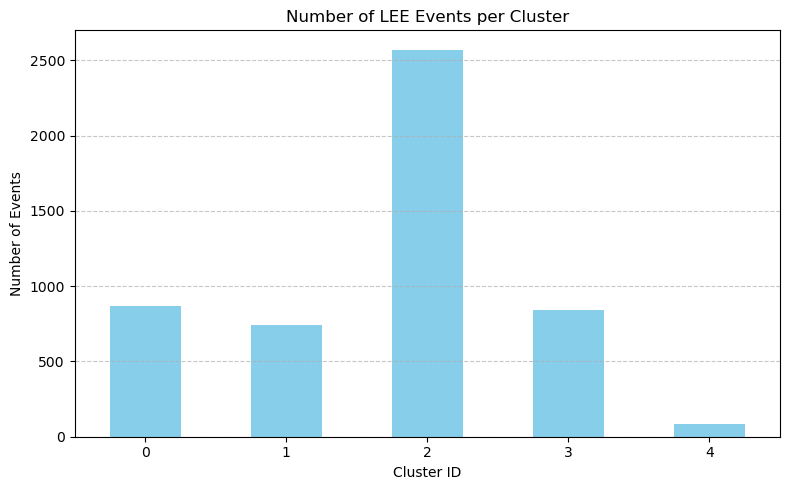

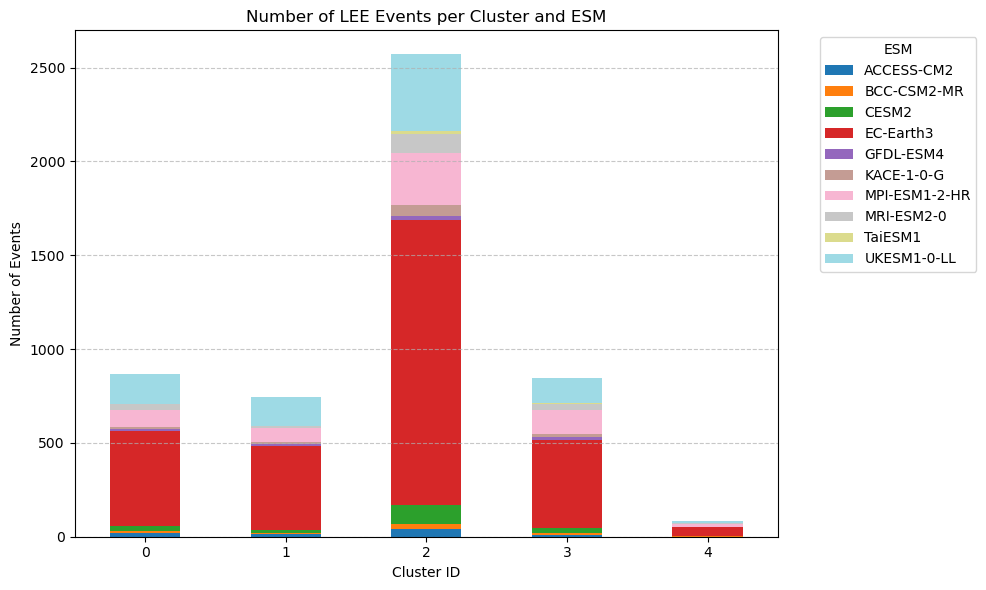

In [45]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_1_subset['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_1_subset.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

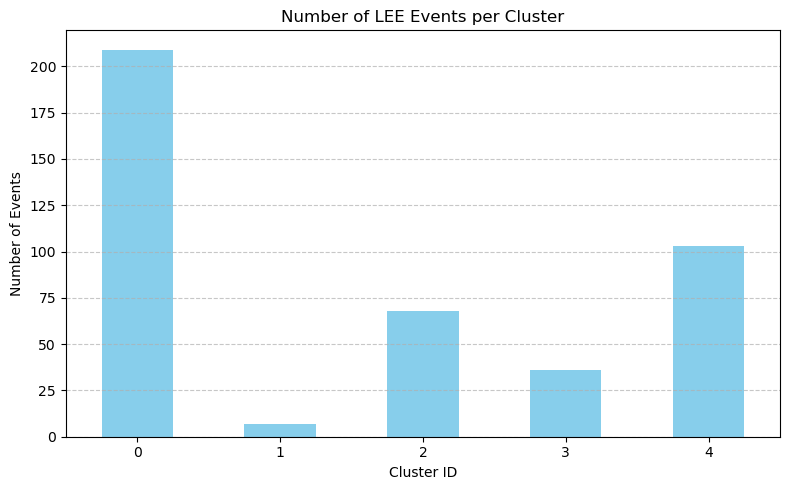

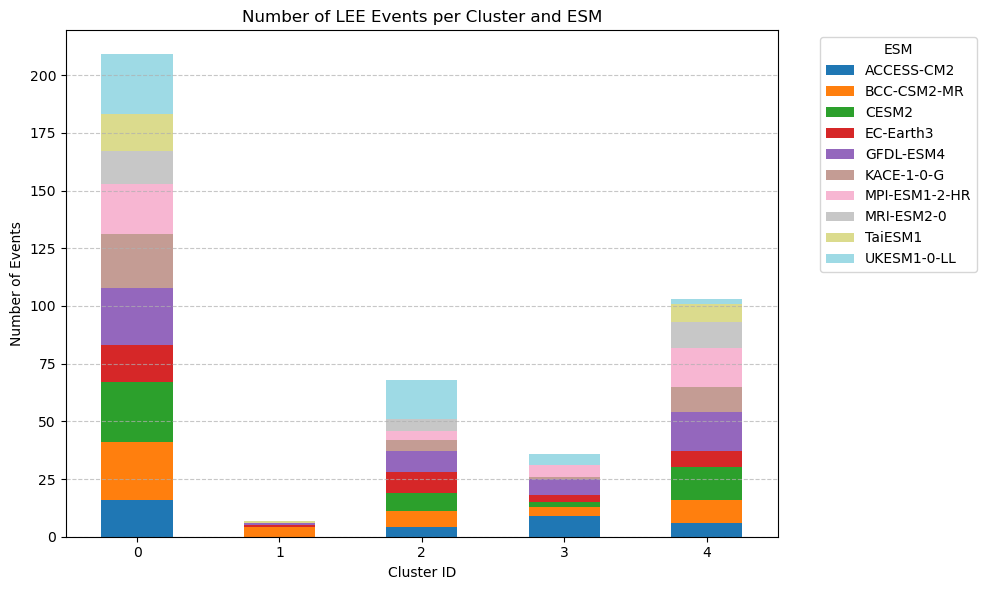

In [142]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_1_subset['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_1_subset.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

In [ ]:
ts = 9

/tmp/ipykernel_4079217/1653708652.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


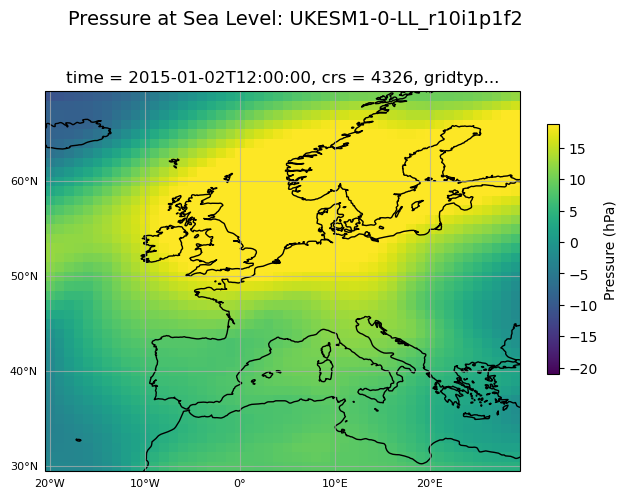

In [ ]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run=LEE_1_subset['ESM_run'].iloc[ts], time=LEE_1_subset['date_start'].iloc[ts])

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle(f'Pressure at Sea Level: {LEE_1_subset['ESM_run'].iloc[ts]}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


----

#### With PCA und scaling
Seems to have lower silhouette scores --> Worse

In [105]:
# 2.1 Scale (standardize) so each “feature” has zero mean & unit variance
scaler = StandardScaler()
X = scaler.fit_transform(arr_flat)
# 2.2 PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X)  # shape: (n_times, n_eofs)
X_pca
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (4, n_eofs)

# 4.1 Convert centroids back to original space
centroids = pca.inverse_transform(centroids_pca) # back to scaled‐PSL
# 4.2 unscale the centroids
centroids_unscaled = scaler.inverse_transform(centroids) # back to anomaly space

# 5. Reshape centroids to lat/lon grid
centroids_reshaped = centroids_unscaled.reshape(k, n_lat, n_lon)  # shape (4, n_lat, n_lon)

score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.15489839


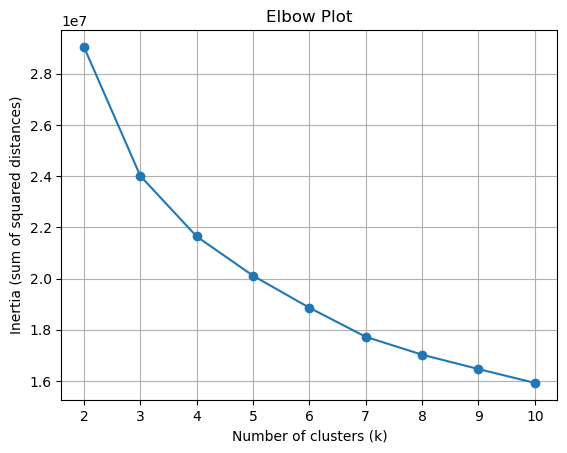

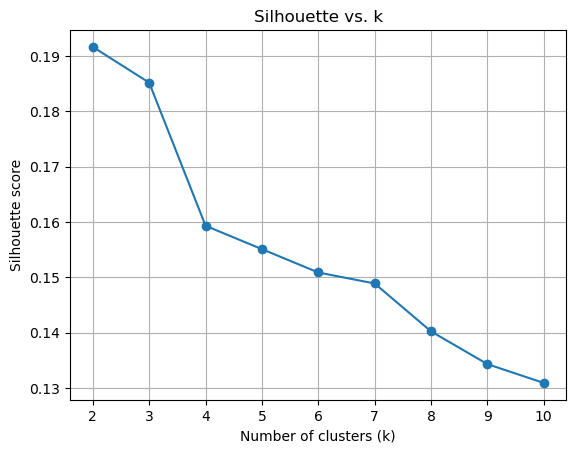

In [ ]:
# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=20, random_state=1)
    labels_k = km.fit_predict(X_pca)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X_pca, labels_k)
    silhouettes.append(silh)

# Plot inertia (elbow)
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(list(k_range), silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()


In [107]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X_pca)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_88847/1150397827.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


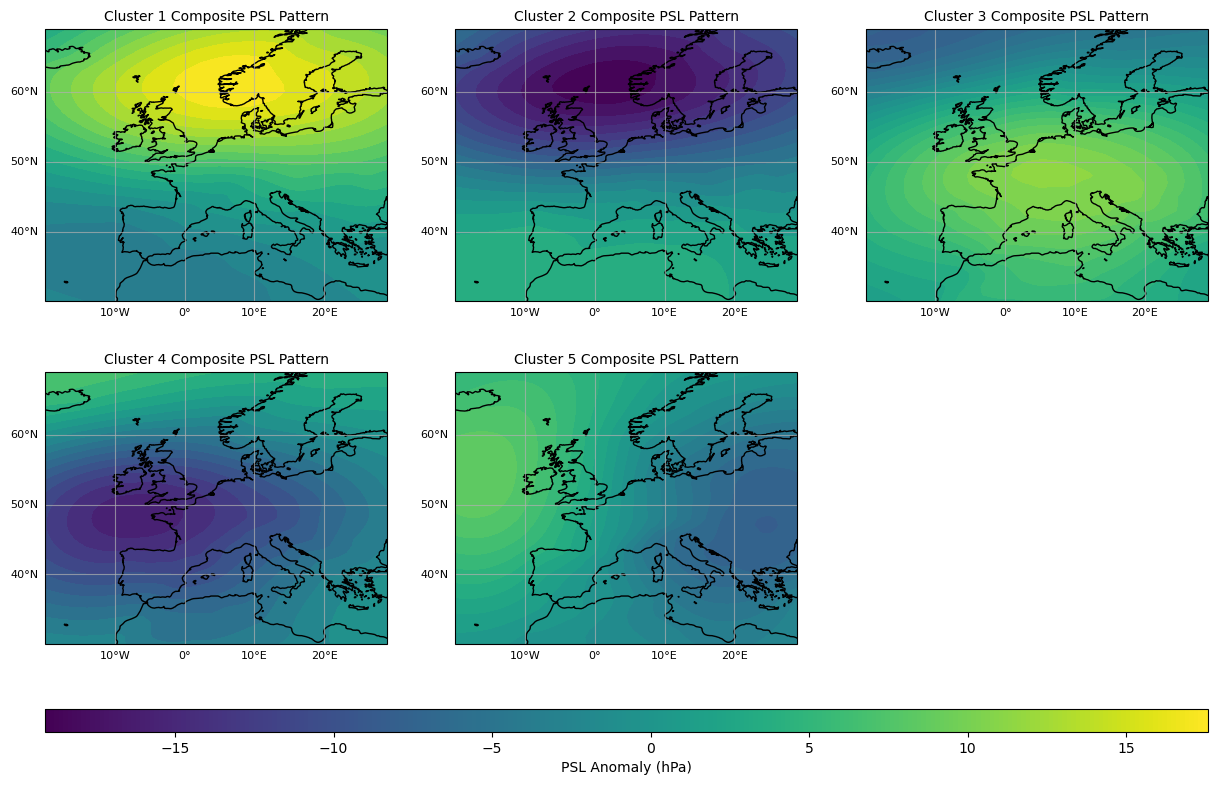

In [108]:
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable

# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


________

#### Without PCA and scaling
Takes quite long and has higher elbow and lower silhouette score --> overall worse

Cluster look the same

In [ ]:
# 2.1 Without standardization
X = arr_flat
# 2.2 Without PCA
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X)
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids = kmeans.cluster_centers_  # shape (4, n_eofs)

# 5. Reshape centroids to lat/lon grid
centroids = centroids.reshape(k, n_lat, n_lon)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.16087487


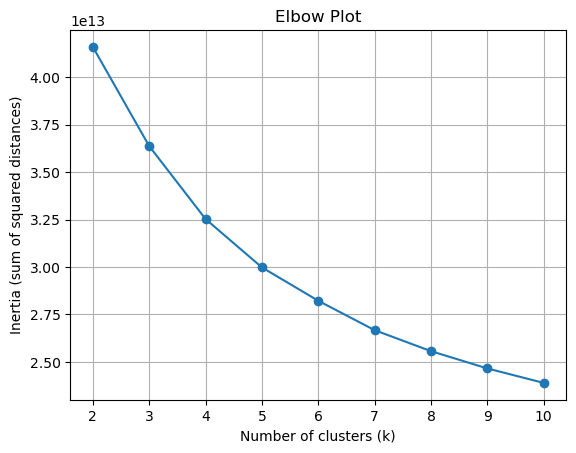

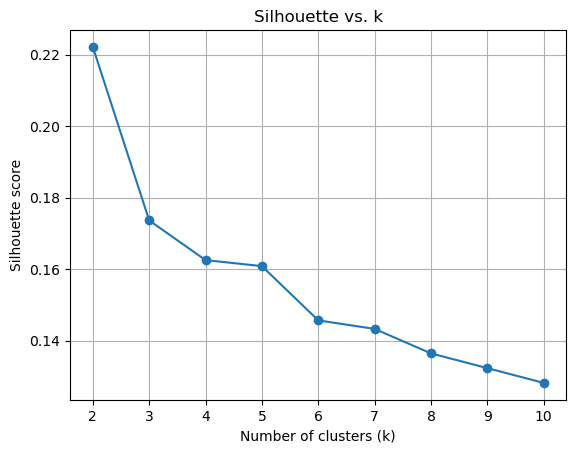

In [ ]:
# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=30, random_state=2)
    labels_k = km.fit_predict(X)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X, labels_k)
    silhouettes.append(silh)

# Plot inertia (elbow)
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(list(k_range), silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()

In [ ]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_88847/191963972.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


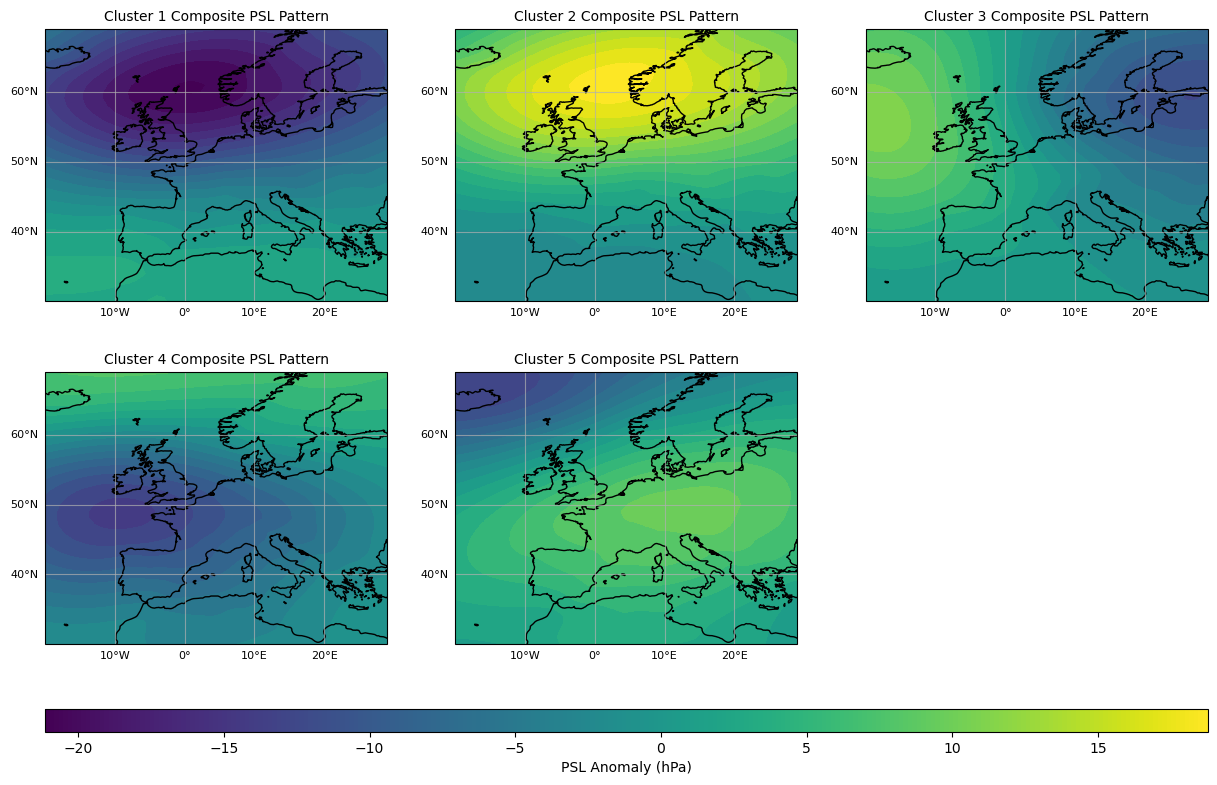

In [ ]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()
